# Libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection

In [32]:
spy_data=yf.download("SPY","2011-08-14","2026-08-13")
spy_data.to_csv("../data/raw.csv")

[*********************100%***********************]  1 of 1 completed


# Info

In [158]:
df=pd.read_csv("../data/raw.csv", header=[0, 1], index_col=0, parse_dates=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3770 entries, 2011-08-15 to 2026-08-12
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   3770 non-null   float64
 1   (High, SPY)    3770 non-null   float64
 2   (Low, SPY)     3770 non-null   float64
 3   (Open, SPY)    3770 non-null   float64
 4   (Volume, SPY)  3770 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.7 KB


In [159]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300


In [160]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500
2026-08-11,770.559998,774.609985,769.200012,774.530029,36740600
2026-08-12,772.489990,774.900024,771.280029,774.710022,33179100


In [161]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,3770.000000,3770.000000,3770.000000,3770.000000,3.770000e+03
mean,304.377455,305.934992,302.560198,304.317255,9.742406e+07
std,170.289118,171.106706,169.309237,170.258662,5.412523e+07
min,84.868309,86.914171,82.938260,83.648518,2.027000e+07
25%,169.691925,170.335756,168.654123,169.554520,6.235858e+07
50%,250.860550,252.141748,249.469077,250.969279,8.293200e+07
75%,410.381996,412.374052,407.164091,409.863964,1.155060e+08
max,773.260010,776.849976,771.619995,775.849976,5.139113e+08


In [162]:
date_gaps=df.index.to_series().diff()
date_gaps.sort_values(ascending=False).head(10)

Date
2012-10-31   5 days
2022-04-18   4 days
2021-07-06   4 days
2014-02-18   4 days
2013-05-28   4 days
2024-02-20   4 days
2016-01-19   4 days
2012-05-29   4 days
2015-09-08   4 days
2019-01-22   4 days
Name: Date, dtype: timedelta64[us]

In [163]:
df.index.duplicated().sum()

np.int64(0)

In [164]:
(df["Volume"] == 0).sum() 

Ticker
SPY    0
dtype: int64

# Data Cleaning

Fixing Multi Indexing

In [165]:
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3770 entries, 2011-08-15 to 2026-08-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3770 non-null   float64
 1   High    3770 non-null   float64
 2   Low     3770 non-null   float64
 3   Open    3770 non-null   float64
 4   Volume  3770 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.7 KB


In [166]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [167]:
df.duplicated().sum()

np.int64(0)

In [168]:
df = df.sort_index()
df.index.is_monotonic_increasing

True

In [169]:
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

No missing/duplicate values found So no need for imputation.

In [170]:
df.to_csv("../data/processed.csv")

# Exploratory Data Analysis(EDA)

In [171]:
df = pd.read_csv("../data/processed.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df.describe()

,Close,High,Low,Open,Volume
count,3770.000000,3770.000000,3770.000000,3770.000000,3.770000e+03
mean,304.377455,305.934992,302.560198,304.317255,9.742406e+07
std,170.289118,171.106706,169.309237,170.258662,5.412523e+07
min,84.868309,86.914171,82.938260,83.648518,2.027000e+07
25%,169.691925,170.335756,168.654123,169.554520,6.235858e+07
50%,250.860550,252.141748,249.469077,250.969279,8.293200e+07
75%,410.381996,412.374052,407.164091,409.863964,1.155060e+08
max,773.260010,776.849976,771.619995,775.849976,5.139113e+08


## 1. SPY Closing Price Over Time

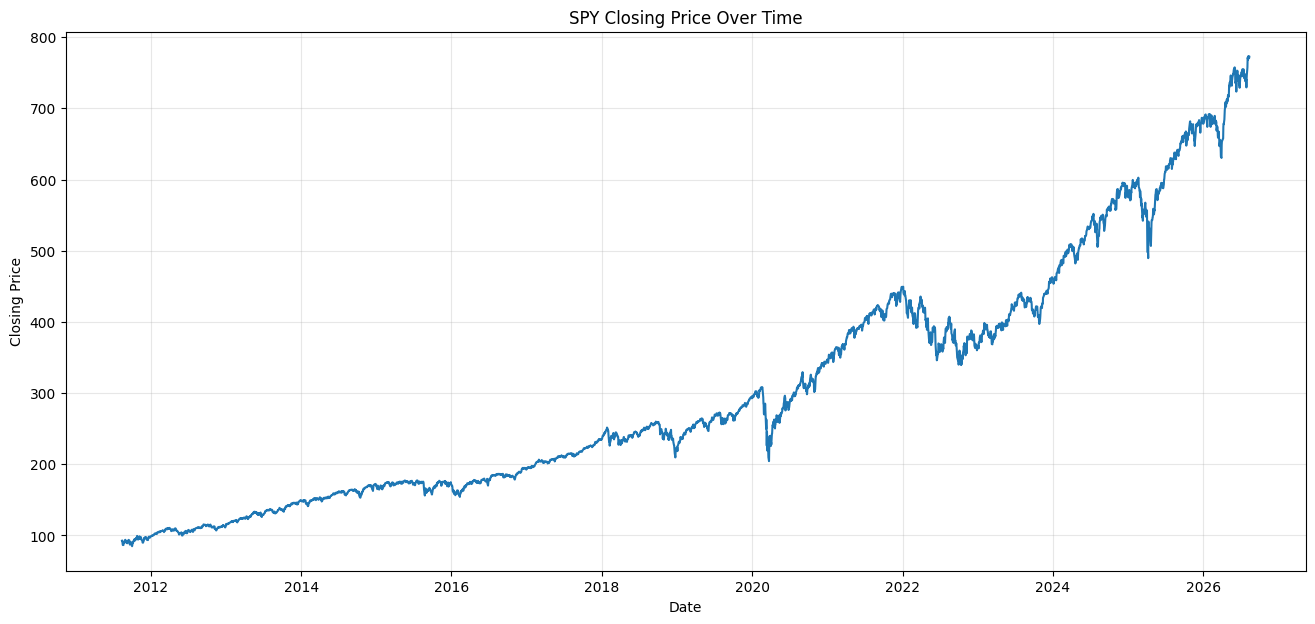

In [172]:
plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Close"])
plt.title("SPY Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True, alpha=0.3)
plt.show()

Graph shows SPY has a strong overall upward trend throughout the 15-year period. A particularly sharp decrease can be observed in early 2020, followed by a strong recovery through 2021 and into 2022. The period from 2022 to 2024 shows greater fluctuations, with a decline followed by a recovery to levels above the previous highs. Early 2025 also shows a sharp decline followed by strong recovery. More recent periods also contain several sharp short-term declines and recoveries, although the overall long-term trend remains upward.

## 2. Daily Returns

In [173]:
df["Daily Returns"]=df["Close"].pct_change()*100
df

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600,NaN
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200,-0.853949
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100,0.066932
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300,-4.311873
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300,-1.633053
...,...,...,...,...,...,...
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900,-0.159781
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300,0.611535
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500,-0.029742


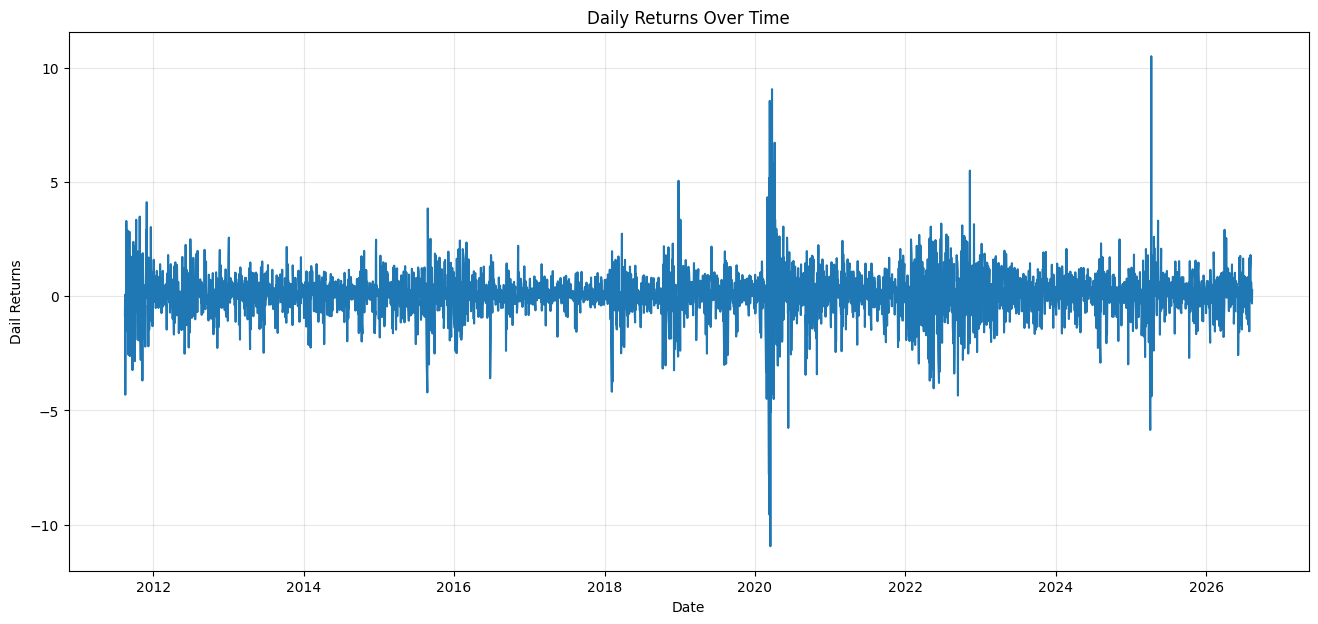

In [174]:
plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Daily Returns"])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Dail Returns")
plt.grid(True, alpha=0.3)
plt.show()

Graph shows most daily returns are concentrated around 0%, indicating that SPY usually experiences relatively small day-to-day price changes. Several periods contain larger positive and negative movements, particularly around 2011-2012, 2015-2016, and 2018. The most extreme and concentrated movements occur around early 2020, with both very large negative and positive returns. After 2020, daily returns are generally closer to zero, although some periods such as 2022–2023 and 2025 contain noticeable spikes.

## 3. Distribution of Daily Returns

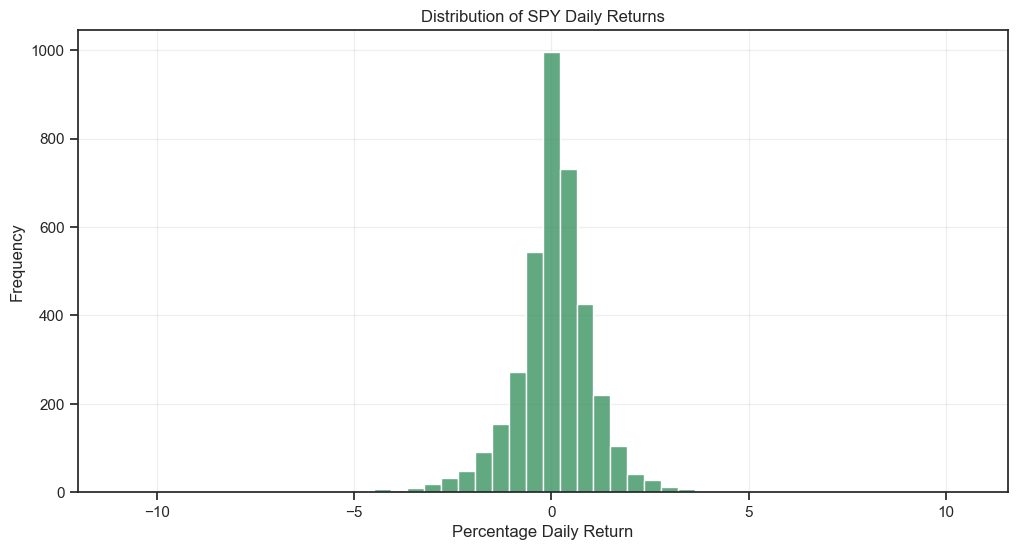

In [175]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="ticks")
sns.histplot(df["Daily Returns"],bins=50,color="seagreen")
plt.title("Distribution of SPY Daily Returns")
plt.xlabel("Percentage Daily Return")
plt.ylabel("Frequency")
plt.grid(True,alpha=0.3)
plt.show()

Graph shows most daily returns are concentrated around 0%, showing that SPY usually experiences relatively small day-to-day price movements. The distribution becomes less frequent as returns move farther away from 0%, with extreme positive and negative returns occurring only occasionally. The distribution has a relatively sharp center and noticeable tails on both sides, indicating that large daily movements are uncommon but do occur. Overall, the histogram is roughly centered around 0% but does not appear to follow a perfect bell-shaped distribution.

## 4. Extreme Daily Returns

In [176]:
df["Daily Returns"].nlargest(5)

Date
2025-04-09    10.501931
2020-03-24     9.060323
2020-03-13     8.548608
2020-04-06     6.716643
2020-03-26     5.838961
Name: Daily Returns, dtype: float64

In [177]:
df["Daily Returns"].nsmallest(5)

Date
2020-03-16   -10.942343
2020-03-12    -9.567710
2020-03-09    -7.809480
2025-04-04    -5.854299
2020-06-11    -5.764905
Name: Daily Returns, dtype: float64

| Period | Extreme movements | General explanation |
|---|---|---|
| March-April 2020 | Very large positive and negative returns | Very large increases and decreases during the COVID-19 market crash and recovery. |
| April 2025 | -5.85% followed by +10.50% | Large decrease followed by a very large increase due to uncertainty around new tariffs and later policy changes. |

Most of the extreme daily returns in the dataset happened during 2020, with some also occurring in 2025. During March-April 2020, SPY had very large increases and decreases because of the COVID-19 pandemic and the uncertainty it caused in the market. In April 2025, SPY also had a large decrease followed by a very large increase due to uncertainty around new tariff announcements and later changes to those policies which shows that extreme daily returns are more common during major events and periods of high market uncertainty.

## 5. Trading Volume Over Time

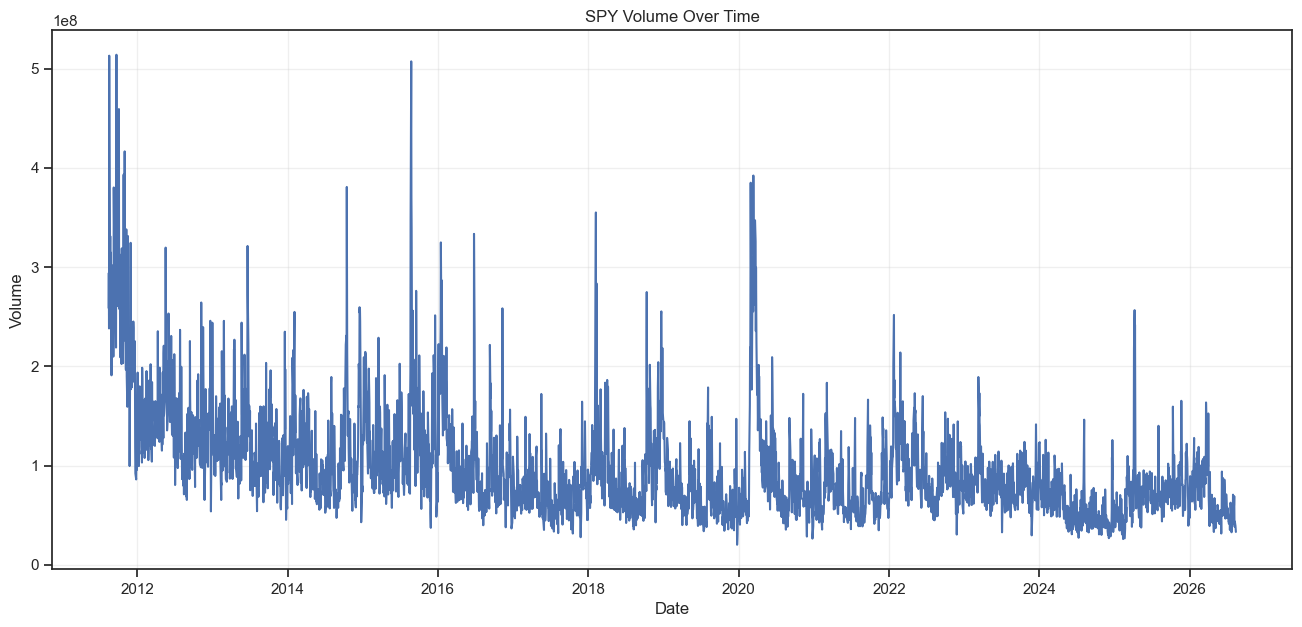

In [178]:
plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Volume"])
plt.title("SPY Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, alpha=0.3)
plt.show()

In [179]:
df["Volume"].nlargest(10)

Date
2011-09-22    513911300
2011-08-18    512956300
2015-08-24    507244300
2011-10-04    459177500
2011-08-19    428281300
2011-11-01    416565800
2011-10-27    393220200
2020-03-12    392220700
2020-02-28    384975800
2014-10-15    380715000
Name: Volume, dtype: int64

Trading volume was especially high during several periods of major market uncertainty. Some of the highest individual volume days occurred in 2011 and 2015, while the COVID-19 period in 2020 had many high-volume days close together. The high volume in these periods often occurred during large market movements and major economic events. This suggests that trading activity tends to increase when there is greater uncertainty in the market.

## 6. Rolling Volatility

In [180]:
df["Rolling Volatility"]=df["Daily Returns"].rolling(20).std()
df

,Close,High,Low,Open,Volume,Daily Returns,Rolling Volatility
Date,,,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600,NaN,NaN
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200,-0.853949,NaN
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100,0.066932,NaN
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300,-4.311873,NaN
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300,-1.633053,NaN
...,...,...,...,...,...,...,...
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900,-0.159781,0.901314
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300,0.611535,0.905542
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500,-0.029742,0.882150


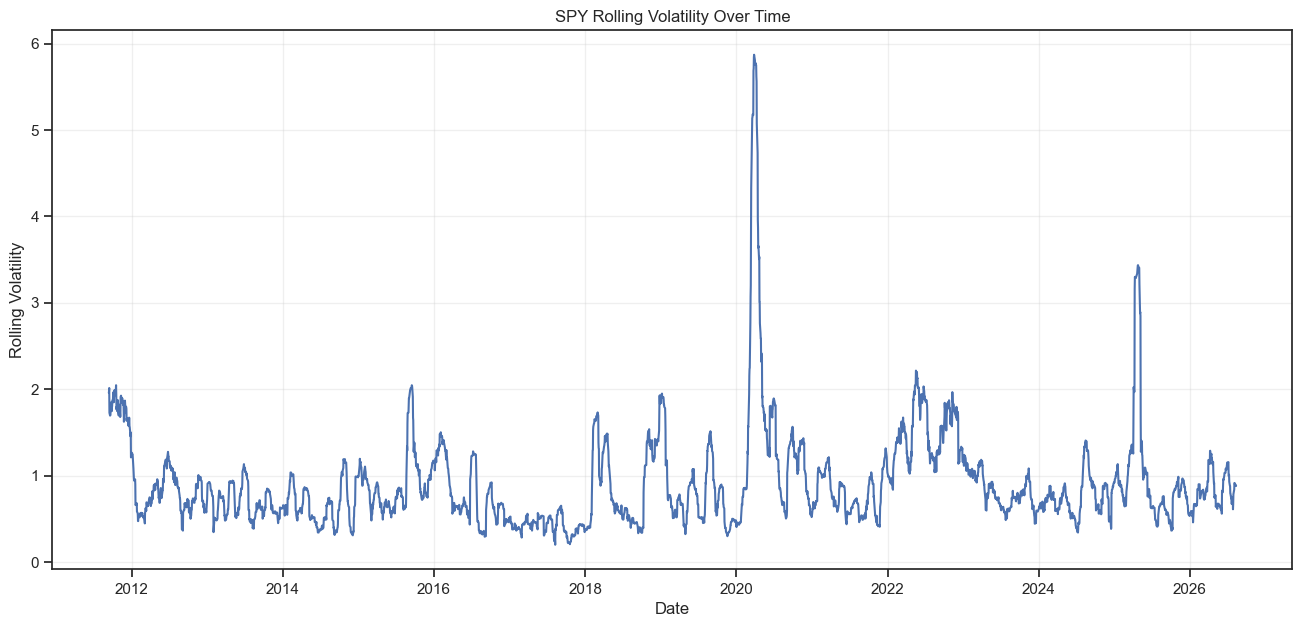

In [181]:
plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Rolling Volatility"])
plt.title("SPY Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True, alpha=0.3)
plt.show()

The rolling volatility was relatively high before 2012 but generally settled into a lower range afterward. Several moderate increases can be seen around late 2015 and 2018–2019. The largest increase occurred during the 2020 COVID-19 market crash, showing an extreme level of market volatility. Volatility later returned to lower levels, with another noticeable increase around the 2025 tariff-related period.

## 7. EDA Summary

SPY showed a strong overall upward trend over the 15-year period, with some major drops, especially during the 2020 COVID-19 crash. Most daily returns were close to 0%, while only a small number of days had very large positive or negative returns. Trading volume was especially high during some periods such as 2011, 2015, and 2020, although the highest individual volume days were not necessarily during the COVID period. Rolling volatility was highest during the 2020 COVID-19 crash, with another noticeable increase around the 2025 tariff-related period. Overall, the data shows that SPY generally moves gradually over time but can experience short periods of very large price movements and increased trading activity.

# Feature Engineering

### Moving Averages

In [182]:
df["10d Moving Avg"]=df["Close"].rolling(10).mean()
df["50d Moving Avg"]=df["Close"].rolling(50).mean()
df

,Close,High,Low,Open,Volume,Daily Returns,Rolling Volatility,10d Moving Avg,50d Moving Avg
Date,,,,,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600,NaN,NaN,NaN,NaN
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200,-0.853949,NaN,NaN,NaN
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100,0.066932,NaN,NaN,NaN
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300,-4.311873,NaN,NaN,NaN
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300,-1.633053,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900,-0.159781,0.901314,750.441003,746.118564
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300,0.611535,0.905542,753.874005,746.613132
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500,-0.029742,0.882150,757.268005,747.020514


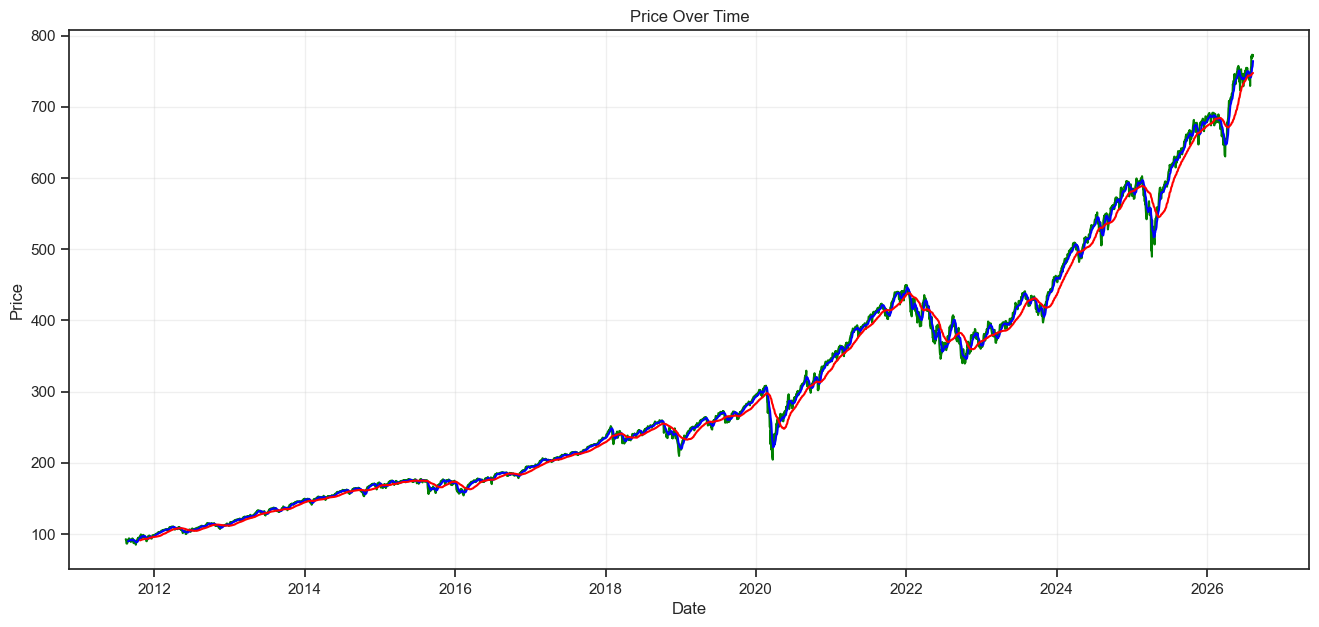

In [183]:
plt.figure(figsize=(16, 7))
plt.plot(df.index,df["Close"],label='Close Price', color='green')
plt.plot(df.index,df["10d Moving Avg"],label='10d Moving Avg', color='blue')
plt.plot(df.index,df["50d Moving Avg"],label='50d Moving Avg', color='red')
plt.title("Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.show()

In [184]:
df["MA Trend"]=(df["10d Moving Avg"]>df["50d Moving Avg"]).astype(int)
df

,Close,High,Low,Open,Volume,Daily Returns,Rolling Volatility,10d Moving Avg,50d Moving Avg,MA Trend
Date,,,,,,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600,NaN,NaN,NaN,NaN,0
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200,-0.853949,NaN,NaN,NaN,0
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100,0.066932,NaN,NaN,NaN,0
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300,-4.311873,NaN,NaN,NaN,0
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300,-1.633053,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900,-0.159781,0.901314,750.441003,746.118564,1
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300,0.611535,0.905542,753.874005,746.613132,1
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500,-0.029742,0.882150,757.268005,747.020514,1


### RSI

In [185]:
df["Price Change"]=df["Close"].diff()
df

,Close,High,Low,Open,Volume,Daily Returns,Rolling Volatility,10d Moving Avg,50d Moving Avg,MA Trend,Price Change
Date,,,,,,,,,,,
2011-08-15,92.641945,92.734107,91.397705,91.543636,258810600,NaN,NaN,NaN,NaN,0,NaN
2011-08-16,91.850830,92.695687,90.867730,91.758668,294095200,-0.853949,NaN,NaN,NaN,0,-0.791115
2011-08-17,91.912308,93.087420,91.182664,92.357777,238201100,0.066932,NaN,NaN,NaN,0,0.061478
2011-08-18,87.949165,91.943012,87.088950,89.477579,512956300,-4.311873,NaN,NaN,NaN,0,-3.963142
2011-08-19,86.512909,89.001382,86.405383,86.758684,428281300,-1.633053,NaN,NaN,NaN,0,-1.436256
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-06,768.559998,771.820007,767.460022,770.210022,38416900,-0.159781,0.901314,750.441003,746.118564,1,-1.229980
2026-08-07,773.260010,773.919983,769.609985,771.020020,43586300,0.611535,0.905542,753.874005,746.613132,1,4.700012
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500,-0.029742,0.882150,757.268005,747.020514,1,-0.229980


In [186]:
df[["Close","Price Change"]].head()

,Close,Price Change
Date,,
2011-08-15,92.641945,NaN
2011-08-16,91.850830,-0.791115
2011-08-17,91.912308,0.061478
2011-08-18,87.949165,-3.963142
2011-08-19,86.512909,-1.436256


In [187]:
df["Gain"] = df["Price Change"].apply(lambda x:x if x > 0 else 0)
df["Loss"] = df["Price Change"].apply(lambda x:abs(x) if x < 0 else 0)
df.loc[df["Price Change"].isna(),["Gain","Loss"]]=np.nan
df[["Price Change","Gain","Loss"]].head()

,Price Change,Gain,Loss
Date,,,
2011-08-15,NaN,NaN,NaN
2011-08-16,-0.791115,0.000000,0.791115
2011-08-17,0.061478,0.061478,0.000000
2011-08-18,-3.963142,0.000000,3.963142
2011-08-19,-1.436256,0.000000,1.436256


In [188]:
df["Avg Gain"]=df["Gain"].rolling(14).mean()
df["Avg Loss"]=df["Loss"].rolling(14).mean()

In [189]:
df["RS"]=df["Avg Gain"]/df["Avg Loss"]

In [190]:
df["RSI"]= (100-(100/(1+df["RS"])))
df["RSI"].describe()

count    3756.000000
mean       57.401148
std        16.054645
min         3.989668
25%        45.996121
50%        57.985255
75%        68.620682
max        97.676682
Name: RSI, dtype: float64

### MACD

In [191]:
df["EMA 12"]=df["Close"].ewm(span=12,adjust=False).mean()
df["EMA 26"]=df["Close"].ewm(span=26,adjust=False).mean()
df["MACD"]=df["EMA 12"]-df["EMA 26"]

In [192]:
df["MACD Signal"]=df["MACD"].ewm(span=9,adjust=False).mean()

In [193]:
df["MACD Histogram"]=df["MACD"]-df["MACD Signal"]

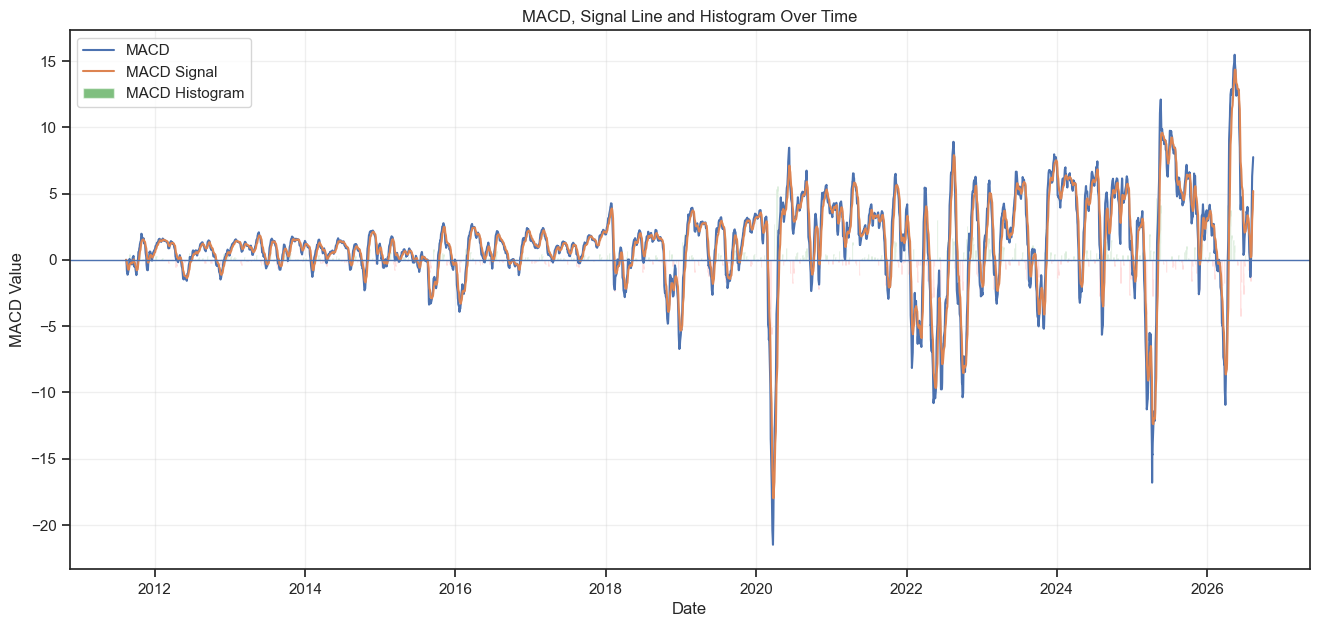

In [194]:
colors = ["green" if x >= 0 else "red" for x in df["MACD Histogram"]]
plt.figure(figsize=(16, 7))
plt.plot(df.index, df["MACD"], label="MACD")
plt.plot(df.index, df["MACD Signal"], label="MACD Signal")
plt.bar(df.index,df["MACD Histogram"],color=colors,alpha=0.5,label="MACD Histogram")
plt.axhline(0, linewidth=1)
plt.title("MACD, Signal Line and Histogram Over Time")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


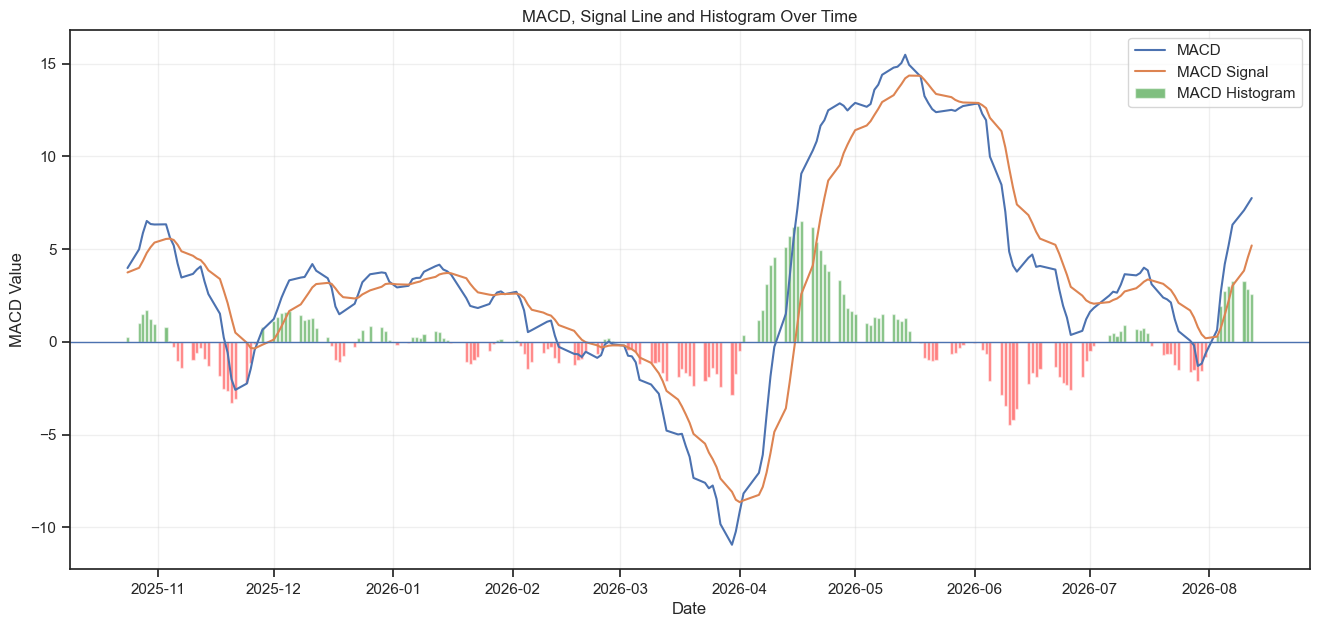

In [195]:
recent = df.tail(200)  #Plotting smaller portion of dataset for better undertsanding
colors = ["green" if x >= 0 else "red" for x in recent["MACD Histogram"]]
plt.figure(figsize=(16, 7))
plt.plot(recent.index,recent["MACD"],label="MACD")
plt.plot(recent.index,recent["MACD Signal"],label="MACD Signal")
plt.bar(recent.index,recent["MACD Histogram"],color=colors,alpha=0.5,label="MACD Histogram")
plt.axhline(0, linewidth=1)
plt.title("MACD, Signal Line and Histogram Over Time")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()

### Bollinger Bands

In [196]:
df["BB Middle"]=df["Close"].rolling(20).mean()
df["BB Std"]=df["Close"].rolling(20).std()
df["BB Upper"]=df["BB Middle"]+(2*df["BB Std"])
df["BB Lower"]=df["BB Middle"]-(2*df["BB Std"])

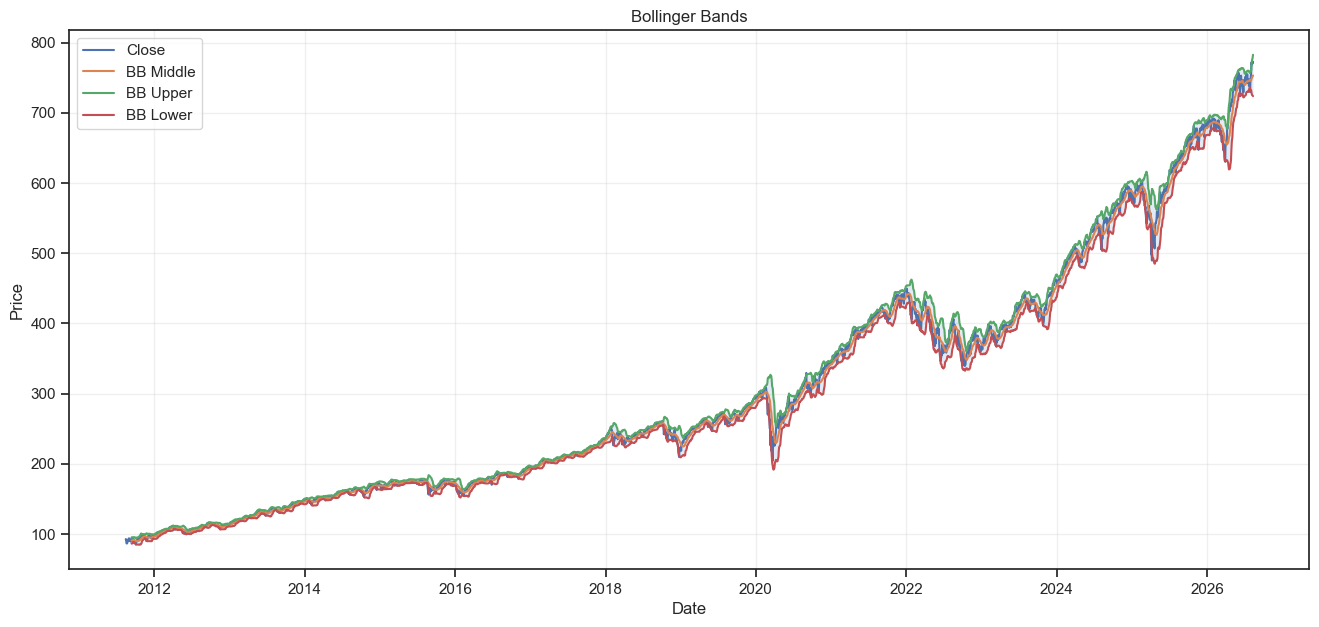

In [197]:
plt.figure(figsize=(16, 7))
plt.plot(df.index,df["Close"],label="Close")
plt.plot(df.index,df["BB Middle"],label="BB Middle")
plt.plot(df.index,df["BB Upper"],label="BB Upper")
plt.plot(df.index,df["BB Lower"],label="BB Lower")
plt.fill_between(df.index,df["BB Lower"],df["BB Upper"],alpha=0.15)
plt.title("Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Volume Ratio

In [200]:
df["20d Avg Volume"]=df["Volume"].rolling(20).mean()

In [204]:
df["Volume Ratio"]=df["Volume"]/df["20d Avg Volume"]
df[["Volume", "20d Avg Volume", "Volume Ratio"]].tail(15)

,Volume,20d Avg Volume,Volume Ratio
Date,,,
2026-07-23,55437300,48502795.0,1.142971
2026-07-24,44782000,48045175.0,0.932081
2026-07-27,41461200,46566535.0,0.890365
2026-07-28,47322200,46030885.0,1.028053
2026-07-29,70697200,46784445.0,1.511126
2026-07-30,66811300,47769965.0,1.398605
2026-07-31,62445900,48019870.0,1.300418
2026-08-03,59927500,48482580.0,1.236063
2026-08-04,69154800,49754245.0,1.389928


### Lag Features

In [206]:
df["Return Lag 1"]=df["Daily Returns"].shift(1)
df["Return Lag 2"]=df["Daily Returns"].shift(2)
df[["Daily Returns", "Return Lag 1", "Return Lag 2"]].head()

,Daily Returns,Return Lag 1,Return Lag 2
Date,,,
2011-08-15,NaN,NaN,NaN
2011-08-16,-0.853949,NaN,NaN
2011-08-17,0.066932,-0.853949,NaN
2011-08-18,-4.311873,0.066932,-0.853949
2011-08-19,-1.633053,-4.311873,0.066932


### Handling NaNs

In [209]:
df.isna().sum()

Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
Daily Returns          1
Rolling Volatility    20
10d Moving Avg         9
50d Moving Avg        49
MA Trend               0
Price Change           1
Gain                   1
Loss                   1
Avg Gain              14
Avg Loss              14
RS                    14
RSI                   14
EMA 12                 0
EMA 26                 0
MACD                   0
MACD Signal            0
MACD Histogram         0
BB Middle             19
BB Std                19
BB Upper              19
BB Lower              19
20d Avg Volume        19
Volume Ratio          19
Return Lag 1           2
Return Lag 2           3
dtype: int64

In [210]:
df = df.dropna()

In [213]:
df.isna().sum()

Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily Returns         0
Rolling Volatility    0
10d Moving Avg        0
50d Moving Avg        0
MA Trend              0
Price Change          0
Gain                  0
Loss                  0
Avg Gain              0
Avg Loss              0
RS                    0
RSI                   0
EMA 12                0
EMA 26                0
MACD                  0
MACD Signal           0
MACD Histogram        0
BB Middle             0
BB Std                0
BB Upper              0
BB Lower              0
20d Avg Volume        0
Volume Ratio          0
Return Lag 1          0
Return Lag 2          0
dtype: int64

In [214]:
df.shape

(3721, 30)

### Feature Correlation Analysis

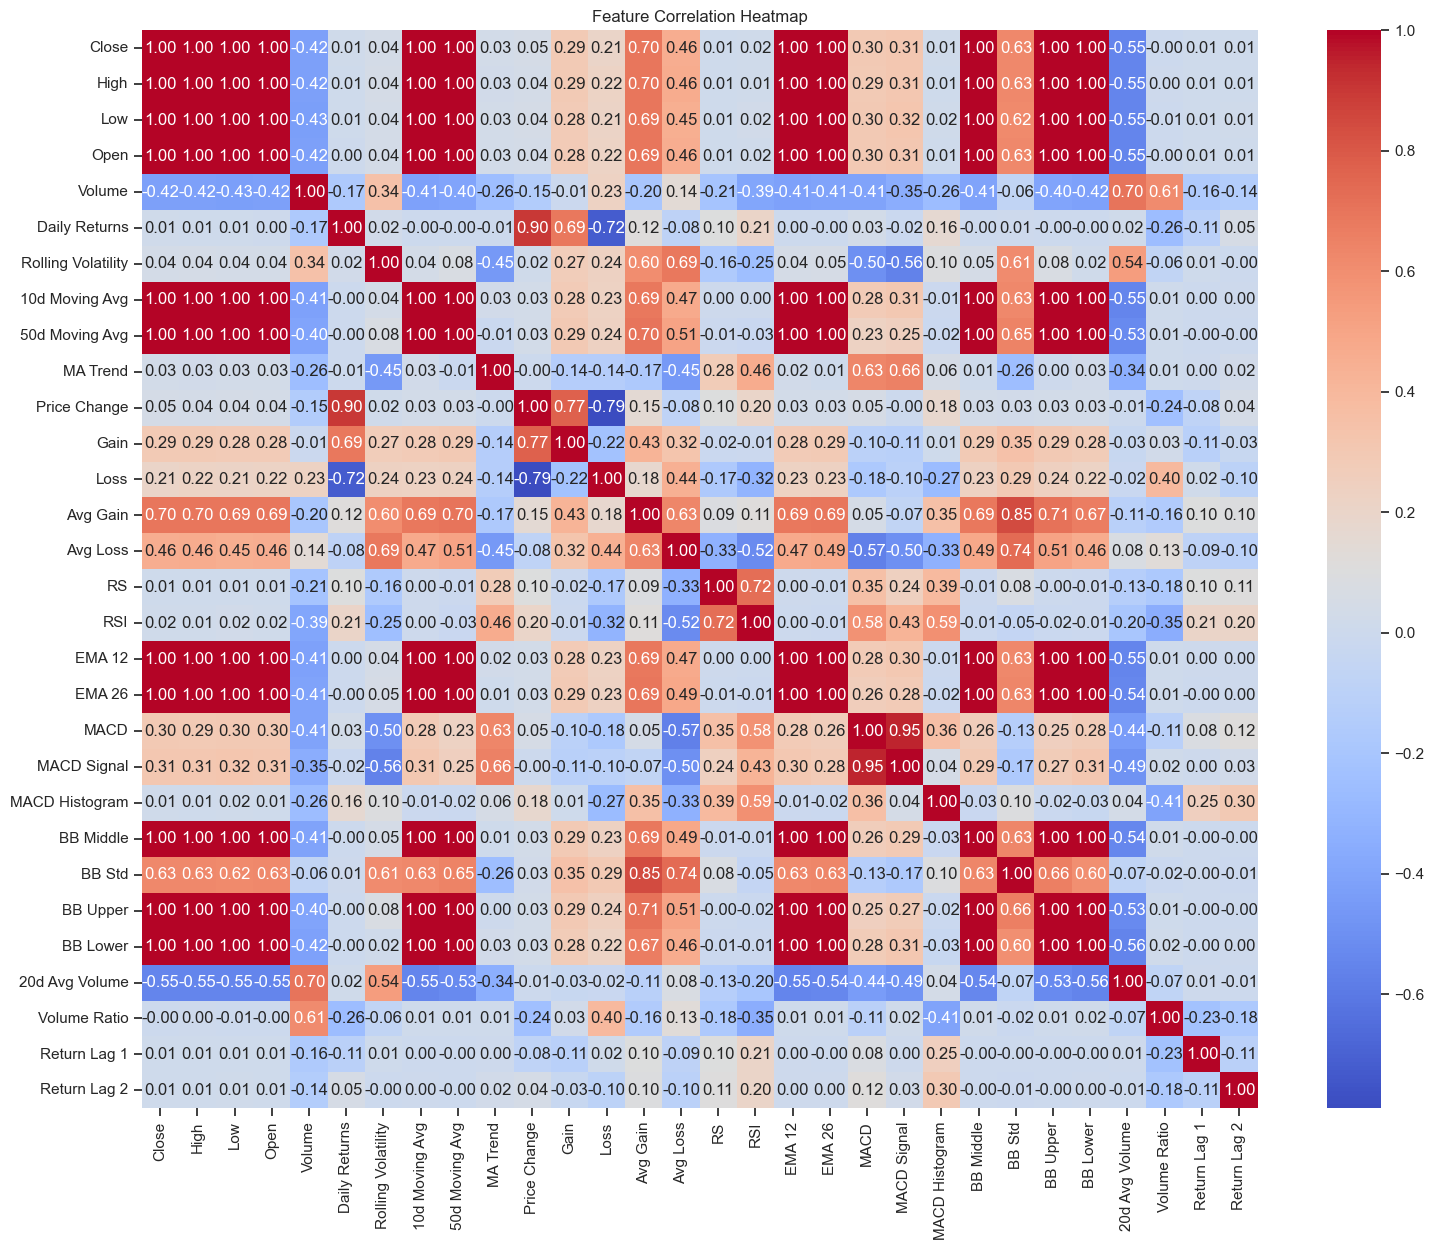

In [224]:
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Saving Feature Engineered Data

In [226]:
df.to_csv("../data/features.csv")

# Target Variable Label Creation

In [366]:
df=pd.read_csv("../data/features.csv")

### Creating Target Label

In [367]:
df["Target"]=(df["Close"] < (df["Close"].shift(-1))).astype(int)
df=df.iloc[:-1]             #Removing last row as there is no value of tommorow for that
df[["Close","Target"]]

,Close,Target
0,96.880966,0
1,94.997223,1
2,95.962288,1
3,99.305115,0
4,99.281952,0
...,...,...
3715,769.789978,0
3716,768.559998,1
3717,773.260010,0
3718,773.030029,0


### Checking Class Balance

In [368]:
df["Target"].value_counts()

Target
1    2054
0    1666
Name: count, dtype: int64

In [369]:
df["Target"].value_counts(normalize=True)*100

Target
1    55.215054
0    44.784946
Name: proportion, dtype: float64

Target Definition: For each day, the target is 1 if the stock's closing price for the next trading day is higher than its closing price today, and 0 if it is lower or equal.

Design choice: This uses a strict greater-than comparison with no minimum threshold. That means even if there is a very slight increase in price the target would still become 1.